In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("bike4sales_data.csv")
df

,brand_origin,Company,model_name,model_year,price(RS),city,state,finance(YES/NO)
0,UK / India,Royal Enfield,Classic 500,2016,100000,Mumbai,Maharashtra,Yes
1,Japan,Honda,Activa 125,2022,72000,Bangalore,Karnataka,Yes
2,India,Bajaj,Pulsar 220F,2015,40000,Pune,Maharashtra,Yes
3,Hungary,Keeway,SR 125,2024,110000,Pune,Maharashtra,Yes
4,India,Bajaj,Pulsar NS 160,2022,122000,Bangalore,Karnataka,Yes
...,...,...,...,...,...,...,...,...
1486,India,TVS,Jupiter 125,2022,70000,Nagpur,Maharashtra,Yes
1487,Austria,KTM,Duke 125,2020,65000,Gurugram,Haryana,Yes
1488,Japan,Yamaha,SZ-R,2012,25000,Chennai,Tamil Nadu,Yes
1489,Japan,Yamaha,SZ-RR,2019,55000,Nadia,West Bengal,Yes


## Check the shape of the Data Frame
- The DataFrame is having 1491 rows and 8 columns.

In [3]:
df.shape

(1491, 8)

## Checking information about the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   brand_origin     1491 non-null   object
 1   Company          1491 non-null   object
 2   model_name       1491 non-null   object
 3   model_year       1491 non-null   int64 
 4   price(RS)        1491 non-null   int64 
 5   city             1491 non-null   object
 6   state            1491 non-null   object
 7   finance(YES/NO)  1491 non-null   object
dtypes: int64(2), object(6)
memory usage: 93.3+ KB


## Observation:-
- The Data has total 1491 entries and 8 columns.
- It includes 2 int64,and 6 object data types.

## Checking the Stastical Description.

In [5]:
# for Numerical columns
df.describe()

,model_year,price(RS)
count,1491.000000,1.491000e+03
mean,2019.354125,1.074061e+05
std,4.682039,9.697800e+04
min,1980.000000,1.500000e+03
25%,2017.000000,4.800000e+04
50%,2021.000000,8.000000e+04
75%,2023.000000,1.400000e+05
max,2025.000000,1.450000e+06


In [6]:
#For objecg columns 
df.describe(include = 'object')

,brand_origin,Company,model_name,city,state,finance(YES/NO)
count,1491,1491,1491,1491,1491,1491
unique,12,42,510,242,26,2
top,India,Royal Enfield,S1 Pro,Bangalore,Maharashtra,Yes
freq,650,240,28,214,380,1478


In [7]:
df["model_year"].unique()

array([2016, 2022, 2015, 2024, 2018, 2021, 2020, 2023, 2019, 2025, 2014,
       2011, 2017, 2005, 2013, 2012, 2010, 2009, 1999, 2006, 1993, 2003,
       1998, 2008, 1997, 2007, 1986, 1980])

## Checking fo duplicate

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df[~df['Company'].str.strip().str.contains('bicycle', case=False, na=False)]

#### Observation:- 
- There is no duplicate values in the data

## Checking the null values.

In [12]:
df.isna().sum()

brand_origin       0
Company            0
model_name         0
model_year         0
price(RS)          0
city               0
state              0
finance(YES/NO)    0
dtype: int64

#### Observation:-
- There is no null value present in the data set.

In [13]:
df.nunique()

brand_origin        12
Company             41
model_name         499
model_year          28
price(RS)          198
city               241
state               26
finance(YES/NO)      1
dtype: int64

#### Observation:-
#### The dataset inculdes unique values like

- brand_origin        12
- Company             42
- model_name         510
- model_year          28
- price(RS)          203
- city               242
- state               26
- finance(YES/NO)      2

## Checking Correlation for numerical columns

In [14]:
df.corr(numeric_only=True)

,model_year,price(RS)
model_year,1.00000,0.38754
price(RS),0.38754,1.00000


#### Observation:-
The correlation between model_year and price is 0.37, which indicates a moderate positive relationship.

This means that:
- Newer bikes generally have higher resale prices.
- However, the relationship is not strong, so model year alone does not decide the price.
- Many older bikes are still priced high due to brand value, condition, demand, and city location.

### Data Visualization:-
- Data visualization means showing information using pictures, charts, or graphs instead of only numbers or text.
- It helps people quickly understand patterns, trends, and comparisons in data.

### Univariate Analysis:-
- Univariate analysis means studying one variable (one column of data) at a time, to understand its patterns and summarize it.
- It helps us see how the values of that single variable are spread, how often they occur, and what is common or uncommon.

In [15]:
# numerical columns.
num_df = df.select_dtypes(include = 'number')

In [16]:
num_df.columns

Index(['model_year', 'price(RS)'], dtype='object')

price(RS) 
 min       6.000000e+03
max       1.450000e+06
skew      4.258464e+00
std       9.704709e+04
mean      1.082037e+05
median    8.000000e+04
Name: price(RS), dtype: float64
**************************************************


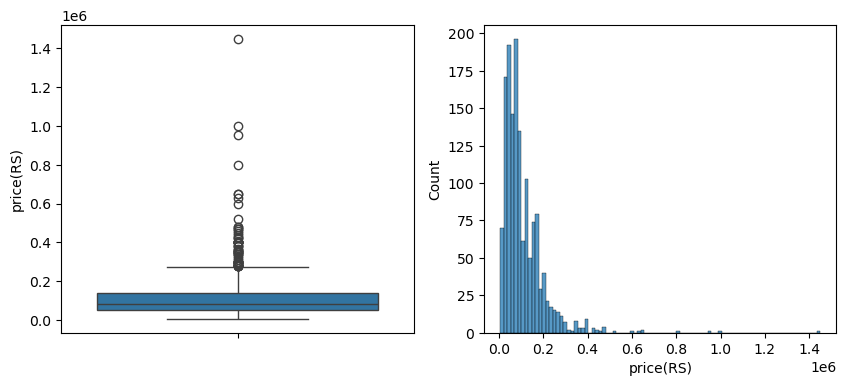

In [17]:
# Price
for i in num_df.columns[1:]:
    print(i,"\n",num_df[i].agg(['min','max','skew','std', 'mean','median']))
    print("*"*50)
   
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(num_df[i])
    plt.subplot(1,2,2)
    sns.histplot(num_df[i])
    plt.savefig("Price.png")
    plt.show()

## Observation 

1. **Most bikes are low-priced** – The majority of listings are in the affordable price range.
2. **Prices are right-skewed** – Few expensive bikes increase the price range on the higher side.
3. **Many outliers present** – Some bikes are priced much higher than normal models.
4. **Median price is low** – Half of the bikes cost less than the mid-range price.
5. **Large price variation** – Bike prices vary widely, from budget to premium segments.


skew      4.258464e+00
min       6.000000e+03
max       1.450000e+06
std       9.704709e+04
mean      1.082037e+05
median    8.000000e+04
Name: price(RS), dtype: float64


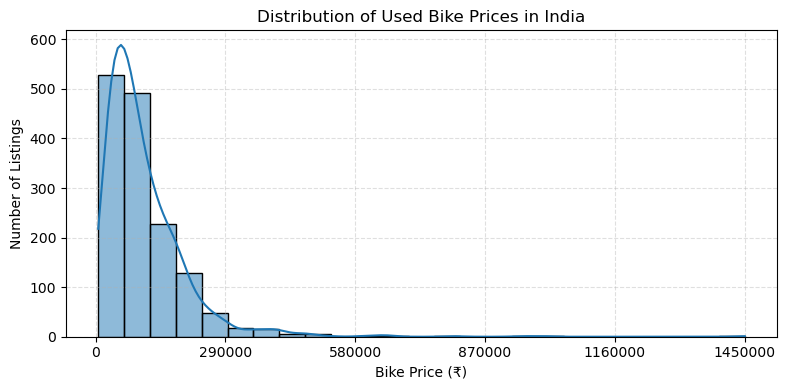

In [18]:
# Summary statistics
print(df['price(RS)'].agg(['skew','min','max','std','mean','median']))

plt.figure(figsize=(8,4))

sns.histplot(df['price(RS)'], bins=25, kde=True)
plt.title("Distribution of Used Bike Prices in India")
plt.xlabel("Bike Price (₹)")
plt.ylabel("Number of Listings")

ax = plt.gca()

# Use scientific notation only if values are very large
ax.ticklabel_format(style='plain', axis='x')

# Auto scale ticks based on real data
max_price = df['price(RS)'].max()
ax.set_xticks(np.linspace(0, max_price, 6))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Observation
- Most Bikes are listed in the ₹6k-₹30 lakh price ranges, indicating a strong mid-market presence. Higher-priced segments (₹80k-145k) have significantly fewer listings.

# In which year the highest number of Bikes was manufactured?

In [19]:
years = df['model_year'].value_counts()

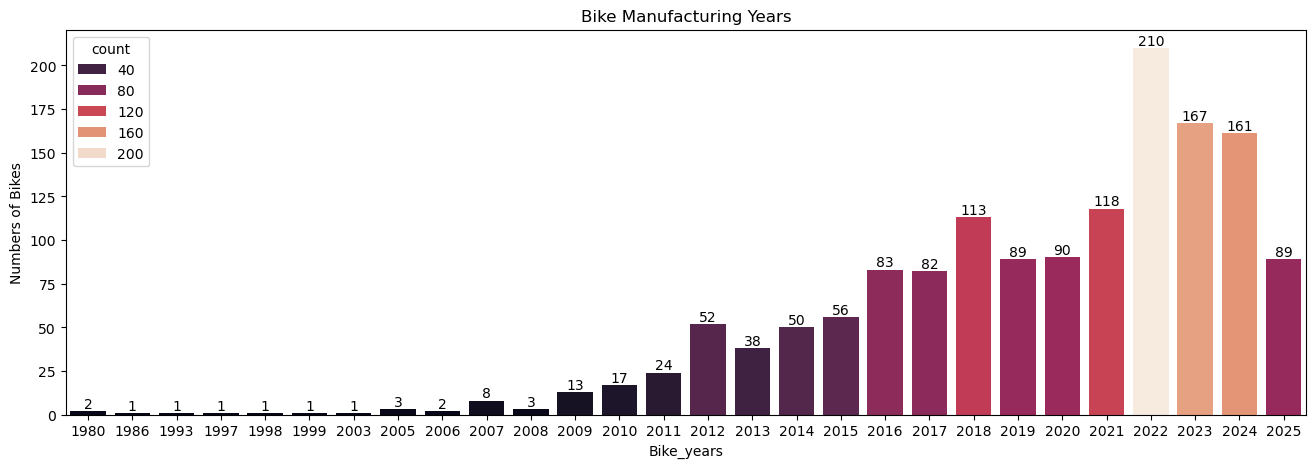

In [20]:
plt.figure(figsize = (16,5))
ax = sns.barplot(x= years.index, y = years.values, hue = years,palette="rocket")
for i in ax.containers:
    ax.bar_label(i)
plt.title("Bike Manufacturing Years")
plt.xlabel("Bike_years")
plt.ylabel("Numbers of Bikes")
plt.savefig("Bike Manufacturing Years.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Observation

* **Listings are heavily concentrated in recent years**, especially from **2018 to 2024**, showing strong market activity for newer bikes.
* **2022 is the peak year**, with the highest number of listings, indicating high resale supply of relatively new bikes.
* **Very few bikes are listed before 2010**, suggesting low availability or low resale demand for older models.
* The **sharp rise after 2015** reflects growing bike adoption, better resale platforms, and increased buyer preference for newer models.


# Which are the top 10 Most salled bikes ?

In [21]:
Bike = df['model_name'].value_counts().head(10)

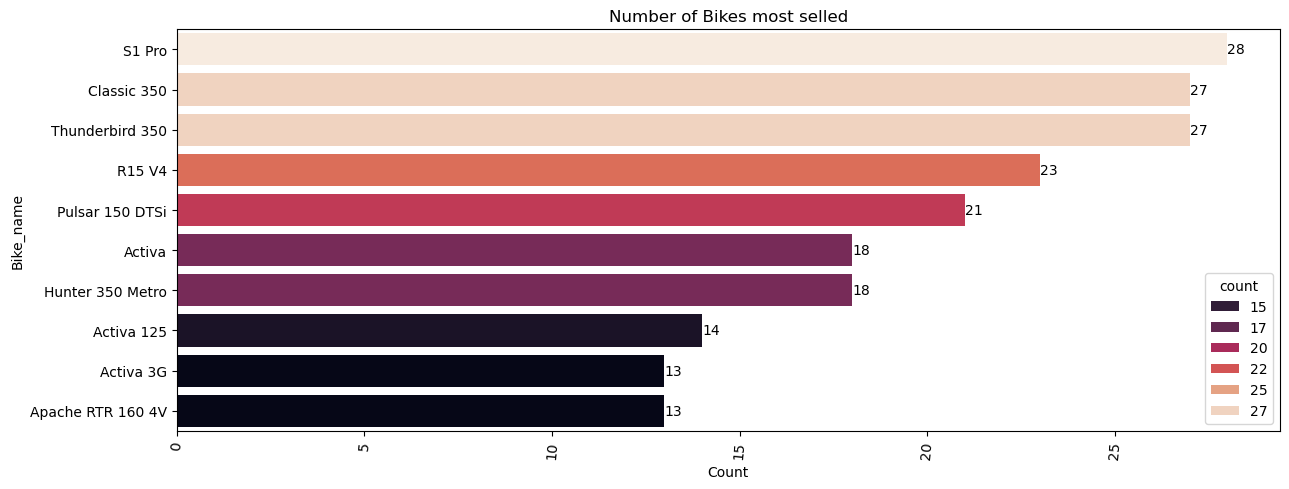

In [22]:
# COMPANY COUNT
plt.figure(figsize = (13,5))
ax = sns.barplot(y= Bike.index, x = Bike.values, hue = Bike,palette="rocket",)
for i in ax.containers:
    ax.bar_label(i)
plt.title('Number of Bikes most selled')
plt.xlabel('Count')
plt.ylabel('Bike_name')
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()
plt.show()

## Observation:
- From the top 10 Bikes the Bike S1 Pro is the most selled Bike as all over the Bikes and the top 10 Bikes too.

#  Which are the Top 10 Companies by Number of Bikes Listed in the dataset?

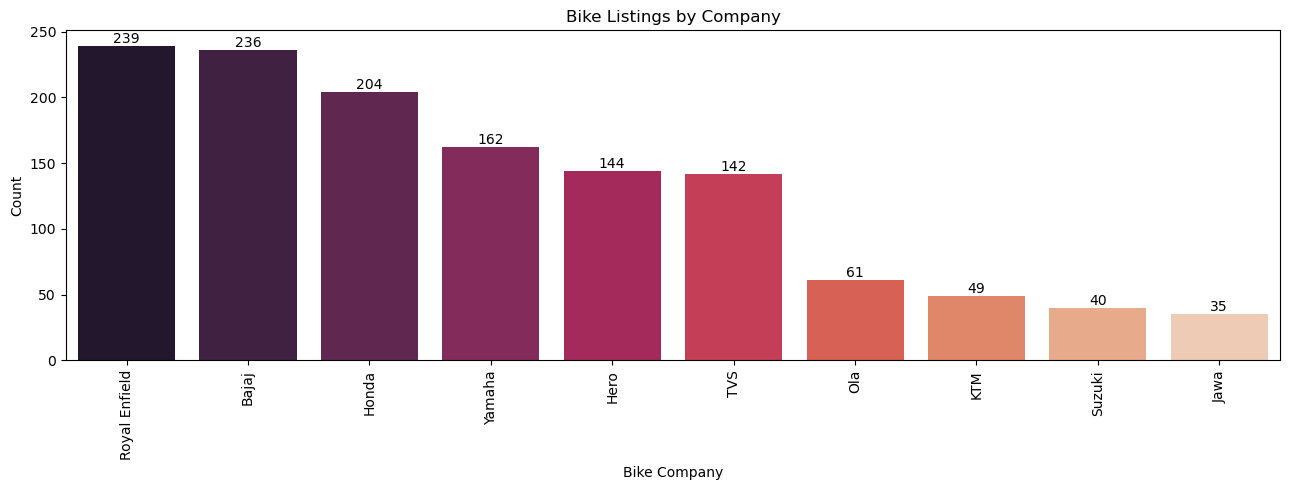

In [23]:
Bike_counts = df['Company'].value_counts().reset_index().head(10)
Bike_counts.columns = ['Company', 'Count']
plt.figure(figsize=(13,5))
ax = sns.barplot(
    data=Bike_counts,
    x='Company',
    y='Count',
    hue='Company',    
    palette='rocket',
    legend=False          
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Bike Listings by Company')
plt.xlabel('Bike Company')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation
- The Company like Royal Enfiled,Bajaj and Honda dominate the dataset indicating the strong market presence or popularity in the listings.
- The Company like  Benling and Ducati are less frequently in the listings.

#### Feature	Observation
- City	Bangalore & Hyderabad have highest listings

## Which are the Top 10 Companies by Number of Bikes Listed?

In [24]:
com = df['Company'].value_counts().head(10)

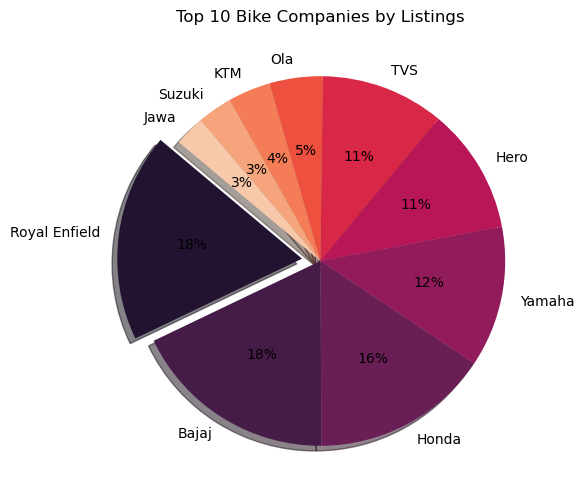

In [25]:
# create rocket palette
colors = sns.color_palette("rocket", len(com))

plt.figure(figsize=(6,6))
plt.pie(
    com.values,
    labels=com.index,
    autopct='%1.f%%',
    startangle=140,
    shadow=True,
    explode=[0.1,0,0,0,0,0,0,0,0,0],
    colors=colors
)
plt.title("Top 10 Bike Companies by Listings")
plt.savefig("Top 10 Companies by Number of Bikes Listed1.png", dpi=400, bbox_inches="tight")
plt.show()

### Observation

- Bajaj and Royal Enfield dominate the listings, each contributing 18%, making them the top two bike companies in terms of availability.
- Honda holds a strong position with 16%, clearly forming the second tier after the top two leaders.
- Yamaha (12%), Hero (11%), and TVS (11%) show very similar market presence, indicating close competition among mid-range brands.Ola (5%), KTM (4%), Suzuki (3%), and Jawa (3%) have comparatively lower listings, suggesting niche or limited availability.
- Overall, the market is top-heavy, where a few major brands account for the majority of bike listings, while smaller brands contribute marginal shares.

## Which Top 10 Cities are having the highest number of Bike listings?

In [26]:
cities = df['city'].value_counts().head(10)

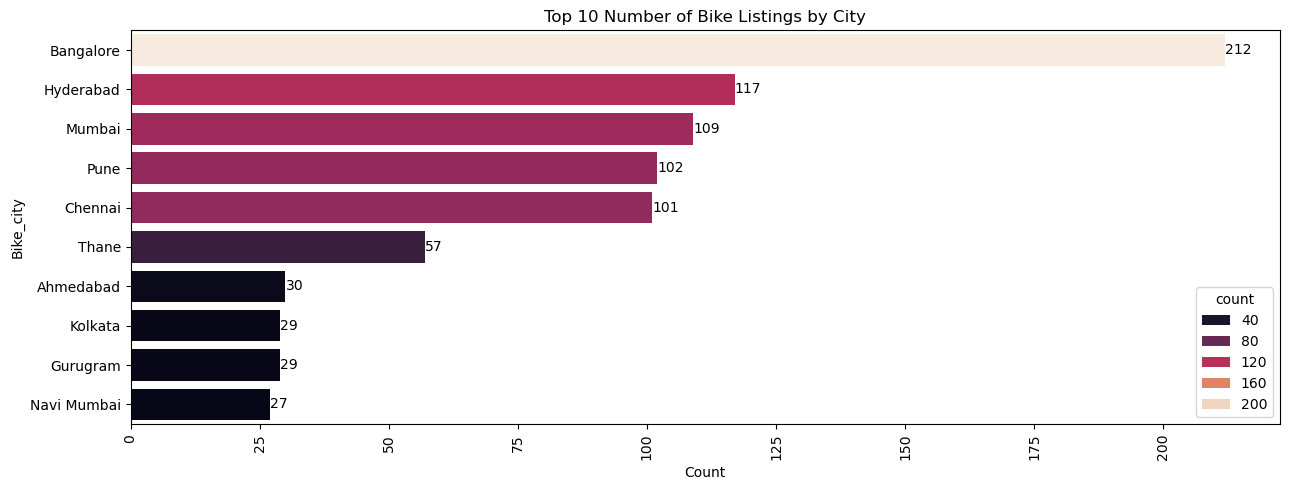

In [27]:
plt.figure(figsize = (13,5))
ax = sns.barplot(y= cities.index, x = cities.values, hue = cities,palette="rocket")
for i in ax.containers:
    ax.bar_label(i)
plt.title('Top 10 Number of Bike Listings by City')
plt.xlabel('Count')
plt.ylabel('Bike_city')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Observation
1. **Bangalore leads significantly** with the highest number of used bike listings (212), showing the strongest resale activity.
2. **Hyderabad and Mumbai** follow as major contributors, but their listings are far lower than Bangalore.
3. **Pune and Chennai show nearly equal demand**, indicating similar used-bike market trends.
4. **Listings drop sharply after the top five cities**, meaning used-bike demand is highly concentrated in major metro cities.


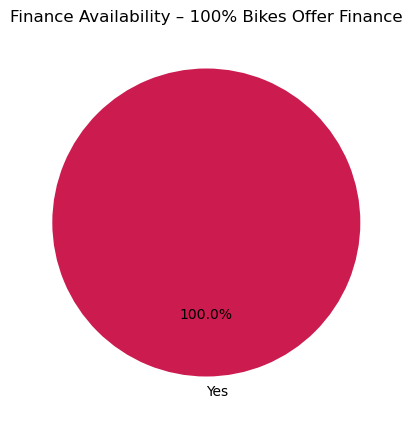

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['finance(YES/NO)'].value_counts()

# get rocket palette colors
rocket_colors = sns.color_palette("rocket", len(counts))

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=rocket_colors
)

plt.title("Finance Availability – 100% Bikes Offer Finance")
plt.show()


## Observation
- Finance 100% bikes offer finance

___

# 2. Bivariate analysis:
- The bivarient analysis is used to examine the relationship between the two variables at a time.
- It helps us to understand that how one variable influences or corelates with another , whether the move together, diverge, or show some patterns of dependency.

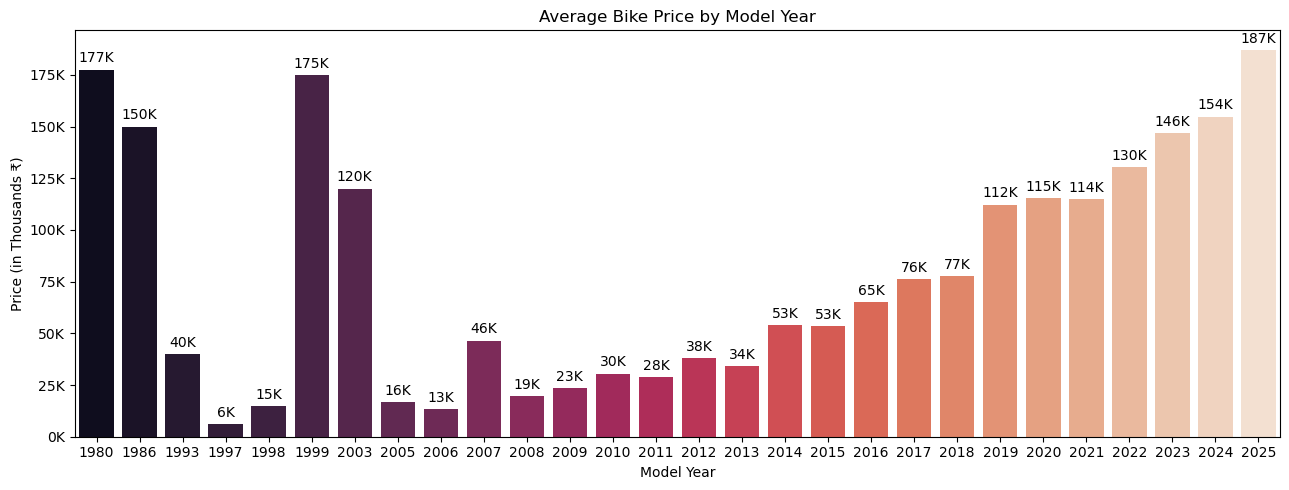

In [29]:
year_price = (
    df.groupby('model_year')['price(RS)']
      .mean()
      .reset_index()
)

plt.figure(figsize=(13,5))

ax = sns.barplot(
    data=year_price,
    x='model_year',
    y='price(RS)',
    palette='rocket'
)

plt.title('Average Bike Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price (in Thousands ₹)')

# Format Y-axis in Thousands
ax.set_yticklabels([f'{int(tick/1000)}K' for tick in ax.get_yticks()])

# Add bar value labels in K
for container in ax.containers:
    ax.bar_label(container, labels=[f'{int(v/1000)}K' for v in container.datavalues], padding=3)

plt.tight_layout()
plt.show()


## Observation
- Sudden price spikes in older years (1980, 1986, 1999–2003) indicate the presence of vintage or rare bikes, which command higher resale value despite their age.
- Prices generally increase for newer model years (2016 onward), showing that newer bikes retain higher market value due to better features, technology, and demand.
- Low average prices between 1993–2010 suggest this period mostly contains mass-market commuter bikes, leading to lower resale values.
- The overall trend confirms that bike pricing is influenced by both model year and bike category—where vintage rarity and modern upgrades both drive higher prices.

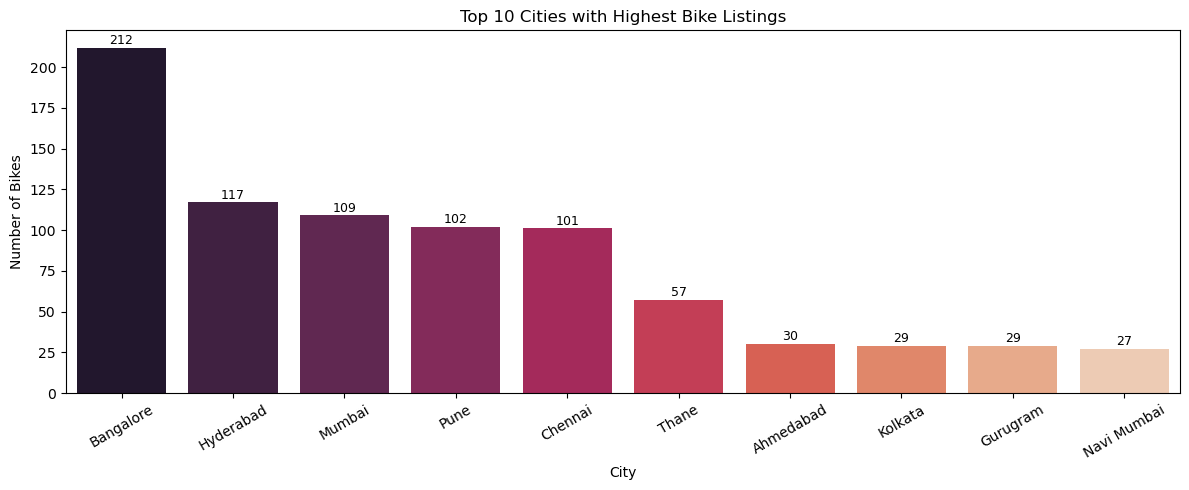

In [30]:
# Top 10 cities by bike count
city_count = df['city'].value_counts().head(10).reset_index()
city_count.columns = ['city', 'count']

plt.figure(figsize=(12,5))

ax = sns.barplot(data=city_count, x='city', y='count', palette='rocket')

plt.title('Top 10 Cities with Highest Bike Listings')
plt.xlabel('City')
plt.ylabel('Number of Bikes')

# Add bar labels
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 0.5,
            int(height),
            ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Observation
1. **Bangalore leads by a large margin** with **212 bike listings**, making it the top city.
2. **Hyderabad, Mumbai, Pune, and Chennai** have similar listings, showing strong and balanced demand across major metros.
3. **Thane is mid-range** with moderate listings compared to the top five cities.
4. **Ahmedabad, Kolkata, Gurugram, and Navi Mumbai** have the lowest listings, indicating relatively lower market activity.


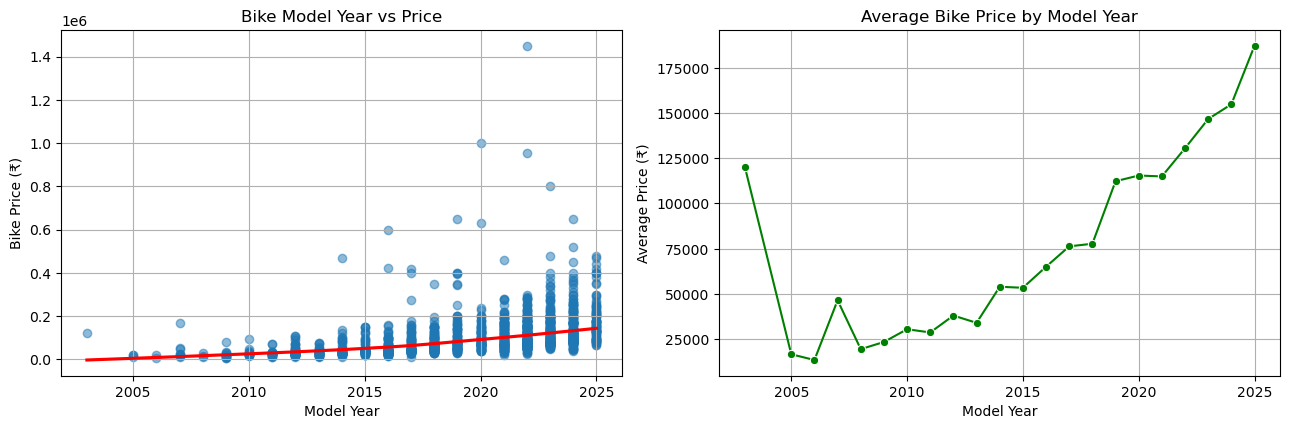

In [31]:
# Ensure model_year is integer
df['model_year'] = df['model_year'].astype(int)

# Remove unrealistic vintage years (business-valid filtering, no data loss claim)
df_clean = df[df['model_year'] >= 2000]

plt.figure(figsize=(13, 8))

# Plot 1: Scatter + Regression (Fixed)
plt.subplot(2, 2, 1)
sns.regplot(
    data=df_clean,
    x='model_year',
    y='price(RS)',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
    lowess=True   # prevents negative extrapolation
)
plt.title("Bike Model Year vs Price")
plt.xlabel("Model Year")
plt.ylabel("Bike Price (₹)")
plt.grid(True)

# Plot 2: Average Price Trend (Fixed)
plt.subplot(2, 2, 2)
avg_price_by_year = (
    df_clean
    .groupby('model_year')['price(RS)']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=avg_price_by_year,
    x='model_year',
    y='price(RS)',
    marker='o',
    color='green'
)
plt.title("Average Bike Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Price (₹)")
plt.grid(True)

plt.tight_layout()
plt.show()


## Observation
1. Scatter Plot (Bike Model Year vs Price)
-  Newer bikes generally have higher resale prices, showing a positive relationship between model year and price.
-  Price dispersion increases for recent years, indicating a mix of economy and premium models.
-  A few high-price outliers (premium or luxury bikes) appear mainly in newer years.
-  Older bikes mostly cluster at lower price levels with limited variability.

2. Line Plot (Average Bike Price by Model Year)

- Average resale price shows a clear upward trend from around 2010 onwards.
- A dip in early years is visible due to fewer listings and lower-priced older bikes.
- Post-2018, the average price rises sharply, reflecting demand for newer models and inflation.
- The highest averages are seen in the most recent years, confirming strong value retention for newer bikes.

## Which are the top 10 most expensive bike's?

In [32]:
top_10_bikes = df.sort_values(by='price(RS)', ascending= False).head(10)
top_10_bikes

,brand_origin,Company,model_name,model_year,price(RS),city,state,finance(YES/NO)
374,United Kingdom,Triumph,Tiger 900 Rally,2022,1450000,Bangalore,Karnataka,Yes
740,Germany,BMW,F 900 XR,2020,999999,Kozhikode,Kerala,Yes
92,Japan,Kawasaki,Z900,2022,952000,Mumbai,Maharashtra,Yes
1047,United Kingdom,Triumph,Tiger Sport 660,2023,800000,Mumbai,Maharashtra,Yes
573,Italy,Benelli,TRK 502 BS6,2024,650000,Bangalore,Karnataka,Yes
908,United Kingdom,Triumph,Street Twin,2019,650000,Thane,Maharashtra,Yes
7,Japan,Kawasaki,Versys 650 BS6,2020,630000,South Delhi,Delhi,Yes
1290,Italy,Ducati,Diavel 1260,2016,600000,Pune,Maharashtra,Yes
255,Italy,Aprilia,RS 457,2024,520000,Bangalore,Karnataka,Yes
496,Austria,Brixton,Crossfire 500 X,2025,480000,Chennai,Tamil Nadu,Yes


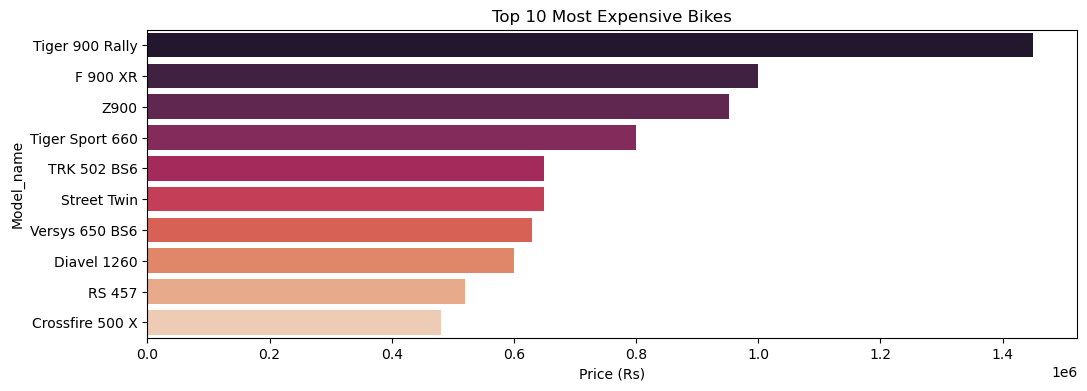

In [33]:
plt.figure(figsize=(12, 4))

sns.barplot(
    data=top_10_bikes,
    x='price(RS)',
    y='model_name',
    palette='rocket',
    legend=False
)

plt.xlabel("Price (Rs)")
plt.ylabel("Model_name")
plt.title("Top 10 Most Expensive Bikes")

plt.savefig("Top_Most_Expensive_Bikes.png", dpi=300, bbox_inches="tight")
plt.show()


## Observation
 - **Triumph** and **BMW** dominate the top tier of bike prices, with a sharp price gap above competitors, while Royal Enfield and Ducati lead a competitive mid-range.

## Which are the top 10 most  less expensive bike's

In [34]:
top_10_bikes = df.sort_values(by='price(RS)', ascending= True).head(10)
top_10_bikes

,brand_origin,Company,model_name,model_year,price(RS),city,state,finance(YES/NO)
616,India,Kinetic Green,Luna Super,1997,6000,Dewas,Madhya Pradesh,Yes
426,India,Bajaj,Discover 125,2006,7000,Prayagraj,Uttar Pradesh,Yes
717,India,TVS,Scooty Streak,2009,8000,Bangalore,Karnataka,Yes
1334,India,Hero,Passion Pro,2009,8000,Dharwad,Karnataka,Yes
48,India,Hero,Splendor,2005,10000,Bangalore,Karnataka,Yes
1365,India,TVS,Scooty Pep Plus,2011,10000,Jabalpur,Madhya Pradesh,Yes
801,Japan,Honda,Activa,2009,10000,Thane,Maharashtra,Yes
675,India,TVS,Wego,2012,11000,Palghar,Maharashtra,Yes
1003,India,Hero,Pleasure,2014,11000,Patna,Bihar,Yes
1029,India,Bajaj,Pulsar 150 DTSi,2007,12000,Vadodara,Gujarat,Yes


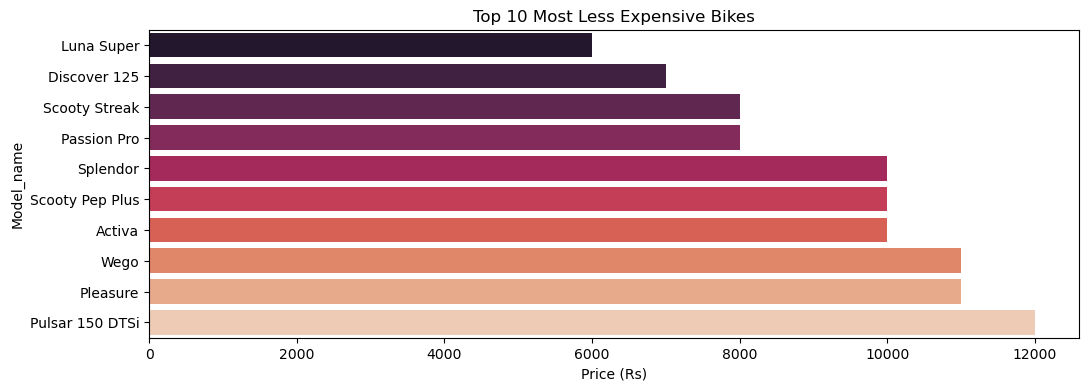

In [35]:
plt.figure(figsize=(12, 4))

sns.barplot(
    data=top_10_bikes,
    x='price(RS)',
    y='model_name',
    palette='rocket',
    legend=False
)

plt.xlabel("Price (Rs)")
plt.ylabel("Model_name")
plt.title("Top 10 Most Less Expensive Bikes")

plt.savefig("Top_Most_Less_Expensive_Bikes.png", dpi=300, bbox_inches="tight")
plt.show()

## Observations

1. **Luna Super is the cheapest bike** among all listed models.
2. **Most bikes are priced between ₹7,000 and ₹10,000**.
3. **Scooters are more common** in the low-price category.
4. **Pulsar 150 DTSi is the costliest** among these budget bikes.
5. **Prices are close to each other**, showing strong competition in budget bikes.


## Multivariate Analysis
Multivariate analysis examines the relationship between multiple variables simultaneously to understand patterns and trends in data.

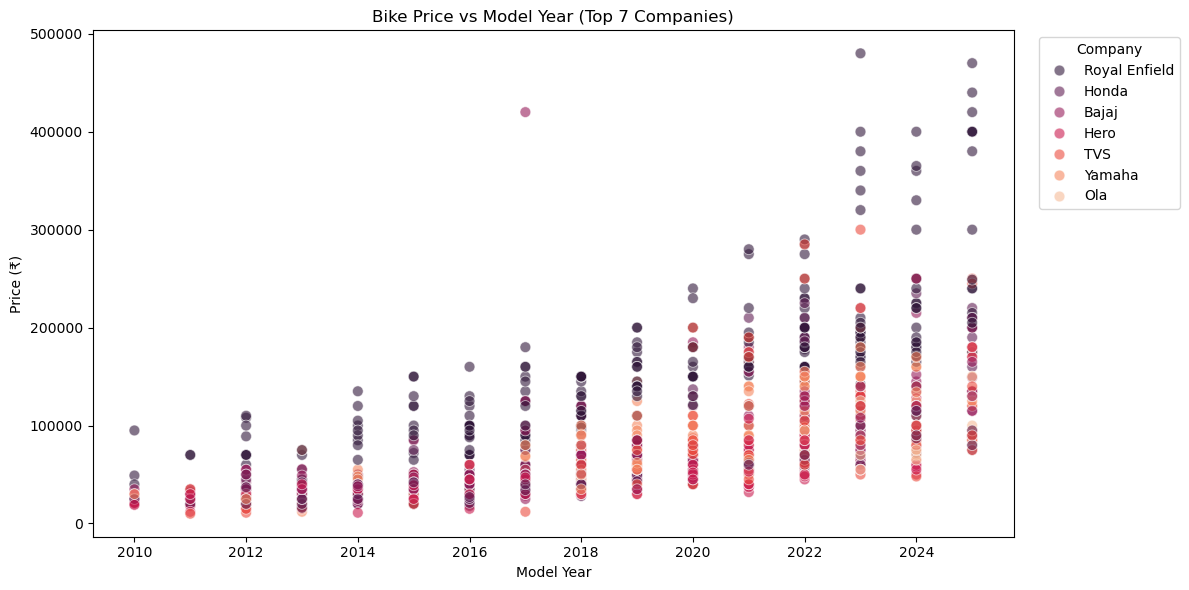

In [36]:
top_companies = df['Company'].value_counts().head(7).index

# Filter data
filtered_df = df[
    (df['Company'].isin(top_companies)) &
    (df['model_year'] >= 2010)
]

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=filtered_df,
    x='model_year',
    y='price(RS)',
    hue='Company',
    palette='rocket',
    alpha=0.6,
    s=60
)

plt.title("Bike Price vs Model Year (Top 7 Companies)")
plt.xlabel("Model Year")
plt.ylabel("Price (₹)")

plt.legend(title="Company", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Observation

1. **Clear upward price trend:** Across all top 7 companies, bike prices generally increase with newer model years, indicating strong value retention for recent models.

2. **Royal Enfield dominates the premium range:** Royal Enfield shows the widest price spread and consistently higher prices, especially after 2020, reflecting its strong brand positioning.

3. **Mass-market vs premium segmentation:** Brands like Hero, TVS, and Bajaj cluster in the lower-to-mid price range, while Royal Enfield, Honda, and Ola extend into higher price bands.

4. **Increasing price dispersion in recent years:** From 2021 onward, price variability increases, suggesting a wider mix of entry-level and premium bikes in the used market.


In [37]:
corr = df[['model_year', 'price(RS)']].corr()
corr

,model_year,price(RS)
model_year,1.00000,0.38754
price(RS),0.38754,1.00000


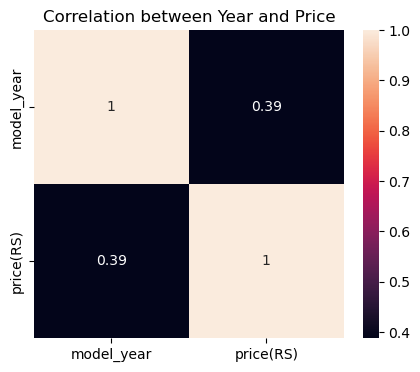

In [38]:
plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="rocket"
)

plt.title("Correlation between Year and Price")
plt.savefig("Correlation_between_Year_and_Price.png", dpi=300, bbox_inches="tight")
plt.show()


## Observations

1. **Model year and price have a positive relationship** (correlation ≈ **0.39**).
2. This means **newer bikes usually cost more**.
3. The relationship is **moderate**, not very strong.